# 🏍️ **Pandas + Seaborn Practice — Bike Resale Listings**

A website sells used bikes. The owner needs answers from the listings.

Solve each question in the empty cell below it.

---



# ⚙️ **0. Setup**

### _Run this cell first — it loads the dataset used throughout the notebook._

---



In [91]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('bike_resale.csv')
df.head()



,bike_id,brand,age_months,km_driven,owner_count,condition,mileage_kmpl,service_count,insurance,price_thousand,sold_in_week
0,B4543,TVS,25,14455.0,3,Excellent,40.6,NaN,Yes,41.6,No
1,B4392,TVS,43,26304.0,2,Good,51.2,1.0,Yes,24.1,No
2,B4235,Honda,38,6421.0,1,Good,65.0,NaN,No,48.2,No
3,B4319,Hero,14,6531.0,1,Good,NaN,NaN,Yes,58.7,No
4,B4284,TVS,115,80000.0,1,Good,61.8,0.0,No,12.0,Yes


# 🎯 **1. Selecting Data**

### _`df[['a','b']]` → select specific columns | `df[df['col'] == x]` → filter rows | combine conditions with `&` / `|`, each wrapped in `()` | `.sort_values()` → order rows_

---



**Q1.1 The website owner wants a short list. Show only the `brand`, `km_driven` and `price_thousand` of the first 10 bikes.**

---



In [92]:
# Write your code here


df[['brand', 'km_driven', 'price_thousand']].head(10)

,brand,km_driven,price_thousand
0,TVS,14455.0,41.6
1,TVS,26304.0,24.1
2,Honda,6421.0,48.2
3,Hero,6531.0,58.7
4,TVS,80000.0,12.0
5,Royal Enfield,5524.0,153.7
6,Hero,22686.0,26.4
7,Yamaha,52795.0,12.0
8,Hero,78402.0,12.0
9,TVS,19605.0,54.8


**Q1.2 A customer only wants a Royal Enfield. Show all Royal Enfield bikes.**

---



In [93]:
# Write your code here
df[df['brand'] == 'Royal Enfield']


,bike_id,brand,age_months,km_driven,owner_count,condition,mileage_kmpl,service_count,insurance,price_thousand,sold_in_week
5,B4533,Royal Enfield,5,5524.0,1,Good,46.9,2.0,No,153.7,No
10,B4394,Royal Enfield,66,49224.0,1,Good,50.9,3.0,No,38.3,Yes
40,B4328,Royal Enfield,16,11870.0,1,Fair,62.6,NaN,Yes,130.0,No
75,B4499,Royal Enfield,25,5779.0,1,Good,44.1,3.0,Yes,111.0,No
76,B4495,Royal Enfield,62,38138.0,1,Excellent,24.1,3.0,Yes,68.2,Yes
83,B4493,Royal Enfield,5,4125.0,1,Excellent,39.8,1.0,Yes,172.3,No
87,B4253,Royal Enfield,44,25018.0,2,Good,NaN,NaN,Yes,75.5,Yes
98,B4217,Royal Enfield,93,63861.0,2,Fair,51.2,1.0,No,12.0,Yes
100,B4303,Royal Enfield,66,44668.0,2,Good,40.8,2.0,Yes,49.7,Yes
101,B4154,Royal Enfield,72,57056.0,2,Good,54.0,NaN,Yes,25.5,Yes


**Q1.3 How many Royal Enfield bikes are there in total?**

---



In [94]:
# Write your code here
royal_enfield_count = df[df['brand'] == 'Royal Enfield'].shape[0]
print(royal_enfield_count)


48


**Q1.4 Another customer wants a bike in **Excellent** condition that costs **less than 30 thousand**. Show only the `brand`, `condition` and `price_thousand` of such bikes.**

---



In [95]:
# Write your code here
df[(df['condition'] == 'Excellent') & (df['price_thousand'] < 30)][['brand', 'condition', 'price_thousand']]



,brand,condition,price_thousand
7,Yamaha,Excellent,12.0
8,Hero,Excellent,12.0
11,Honda,Excellent,12.0
26,Hero,Excellent,12.0
33,Bajaj,Excellent,17.4
...,...,...,...
417,Hero,Excellent,12.0
418,TVS,Excellent,12.0
433,Hero,Excellent,26.7
434,TVS,Excellent,12.0


**Q1.5 Use `.sort_values()` to find the 5 cheapest bikes overall. Show only `brand` and `price_thousand`.**

---



In [96]:
# Write your code here
df.sort_values('price_thousand').head(5)[['brand', 'price_thousand']]



,brand,price_thousand
449,Bajaj,12.0
161,TVS,12.0
359,TVS,12.0
163,Royal Enfield,12.0
167,Yamaha,12.0


# 🧹 **2. Cleaning Data**

### _`.isnull().sum()` → missing values per column | `.duplicated().sum()` → duplicate rows | `.fillna()` → fill missing | `.dropna()` → drop missing_

---



**Q2.1 Before sharing the file, the owner wants to know which columns have blank values, and how many in each.**

---



In [97]:
# Write your code here
df.isnull().sum()



bike_id            0
brand              0
age_months         0
km_driven          9
owner_count        0
condition          0
mileage_kmpl      26
service_count     74
insurance          0
price_thousand     0
sold_in_week       0
dtype: int64

**Q2.2 Check whether the dataset has any repeated (duplicate) rows.**

---



In [98]:
# Write your code here
df.duplicated().sum()



np.int64(0)

**Q2.3 Fill the blanks in `mileage_kmpl` with the average mileage.**

---



In [99]:
# Write your code here

df['mileage_kmpl'].fillna(df['mileage_kmpl'].mean(), inplace=True)

/var/folders/y4/126bn5m904d9hyby0fk5z07h0000gn/T/ipykernel_98403/4153640672.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['mileage_kmpl'].fillna(df['mileage_kmpl'].mean(), inplace=True)


0      40.600000
1      51.200000
2      65.000000
3      47.882075
4      61.800000
         ...    
445    53.900000
446    49.200000
447    48.500000
448    56.000000
449    51.100000
Name: mileage_kmpl, Length: 450, dtype: float64

**Q2.4 Remove the rows where `km_driven` is blank.**

---



In [100]:
# Write your code here
df.dropna(subset=['km_driven'], inplace=True)



**Q2.5 Print the shape of `df` after both cleaning steps above.**

---



In [101]:
# Write your code here

print(df.shape)

(441, 11)


**Q2.6 Run `.isnull().sum()` again to confirm the blanks you handled are gone.**

---



In [102]:
# Write your code here
df.isnull().sum()




bike_id            0
brand              0
age_months         0
km_driven          0
owner_count        0
condition          0
mileage_kmpl      25
service_count     73
insurance          0
price_thousand     0
sold_in_week       0
dtype: int64

# 📊 **3. Grouping Data**

### _`.groupby('col')` → split by group | `.mean()` / `.agg()` → aggregate | `.sort_values()` → order the result | `.value_counts()` → count rows per category_

---



**Q3.1 Which brand sells for the most on average? Find the average price of each brand, from highest to lowest.**

---



In [103]:
# Write your code here
df.groupby('brand')['price_thousand'].mean().sort_values(ascending=False)



brand
Royal Enfield    68.417021
TVS              30.814118
Yamaha           30.487755
Honda            29.241111
Bajaj            27.329487
Hero             25.522826
Name: price_thousand, dtype: float64

**Q3.2 For each `condition`, show the average price **and** the number of bikes in one table using `.agg()`.**

---



In [104]:
# Write your code here
df.groupby('condition')['price_thousand'].agg(['mean', 'count'])



,mean,count
condition,,
Excellent,36.347692,130
Fair,26.356604,106
Good,33.761951,205


**Q3.3 Which brand has the most bikes listed? Use `.value_counts()` on `brand`.**

---



In [105]:
# Write your code here
df['brand'].value_counts().head(1)



brand
Hero    92
Name: count, dtype: int64

# 📈 **4. Plotting**

### _`sns.histplot()` → distribution | `sns.boxplot()` → compare across categories | `sns.countplot(hue=)` → grouped counts | `sns.scatterplot(hue=)` → relationship colored by category | `sns.heatmap()` → correlation matrix_

---



**Q4.1 How far have most bikes been driven? Draw the distribution of `km_driven`.**

---



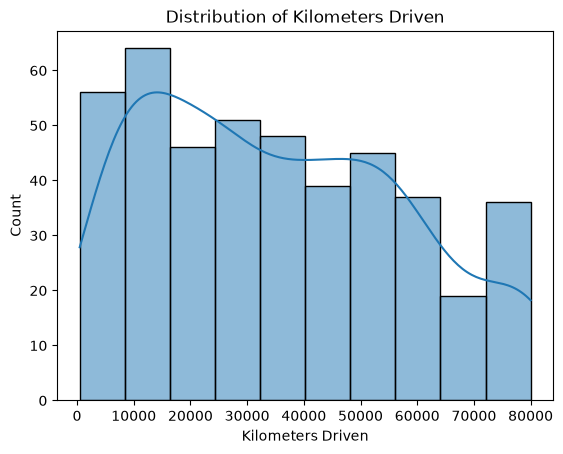

In [106]:
# Write your code here
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df['km_driven'], kde=True)
plt.title('Distribution of Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Count')
plt.show()



**Q4.2 For every brand, show how many bikes were sold in the first week and how many were not, using `sns.countplot()` with `hue='sold_in_week'`.**

---



<Axes: xlabel='brand', ylabel='count'>

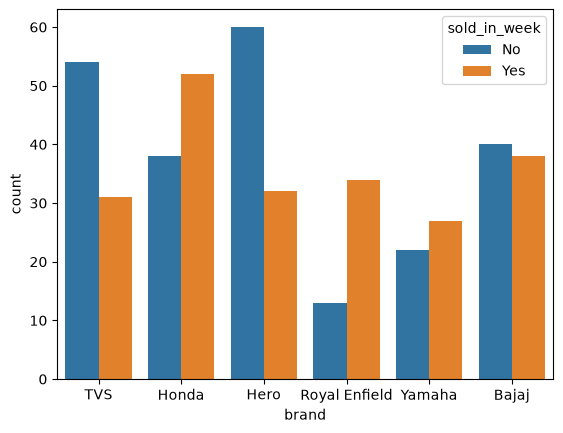

In [119]:
# Write your code here
sns.countplot(data=df, x='brand',hue='sold_in_week')


**Q4.3 A buyer says condition does not change the price. Draw one plot of `price_thousand` for each `condition`.**

---



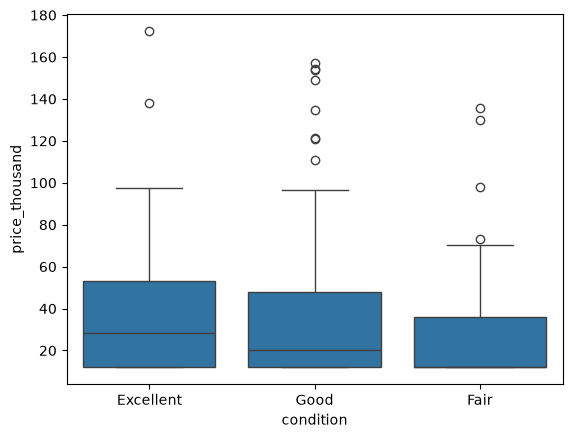

In [120]:
# Write your code here
sns.boxplot(x='condition', y='price_thousand', data=df)
plt.show()



**Q4.4 Looking at the plot above — is the buyer right or wrong? Write your answer as a comment.**

---



In [ ]:
# Write your code here
#the buyer is wrong



**Q4.5 Draw `age_months` against `price_thousand`, coloured by `sold_in_week`.**

---



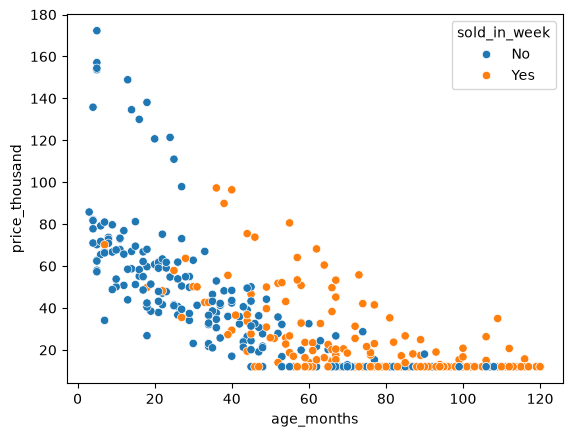

In [110]:
# Write your code here
sns.scatterplot(data=df, x='age_months', y='price_thousand', hue='sold_in_week')
plt.show()


**Q4.6 Based on that scatter plot — what happens to price as a bike gets older? Write your answer as a comment.**

---



In [ ]:
# Write your code here
# when the bike get older the price get decrease 



**Q4.7 Draw a heatmap of the correlation between the numeric columns.**

---



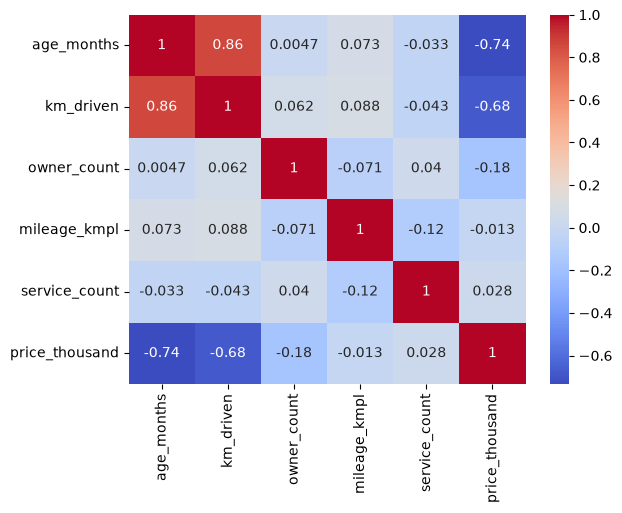

In [112]:
# Write your code here
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()




**Q4.8 From the heatmap — which two columns move together the most? Write your answer as a comment.**

---



In [113]:
# Write your code here

